In [1]:
import pandas as pd
from sklearn.preprocessing import LabelEncoder
from sklearn.tree import DecisionTreeClassifier
from sklearn.tree import plot_tree
from sklearn import tree
import matplotlib.pyplot as plt

In [23]:
data = {
  'Weather': ['Sunny', 'Cloudy', 'Sunny', 'Cloudy', 'Rainy', 'Rainy', 'Rainy', 'Sunny', 'Cloudy', 'Rainy'],
  'Temperature': ['Hot', 'Hot', 'Mild', 'Mild', 'MIld', 'Cool', 'Mild', 'Hot', 'Hot', 'Mild'],
  'Humidity': ['High', 'High', 'Normal', 'High', 'High', 'Normal', 'High', 'High', 'Normal', 'High'],
  'Wind': ['Weak', 'Weak', 'Strong', 'Strong', 'Strong', 'Strong', 'Weak', 'Strong', 'Weak', 'Strong'],
  'Play': ['No', 'Yes', 'Yes', 'Yes', 'No', 'No', 'Yes', 'No', 'Yes', 'No'],
}

df = pd.DataFrame(data)
df


,Weather,Temperature,Humidity,Wind,Play
0,Sunny,Hot,High,Weak,No
1,Cloudy,Hot,High,Weak,Yes
2,Sunny,Mild,Normal,Strong,Yes
3,Cloudy,Mild,High,Strong,Yes
4,Rainy,MIld,High,Strong,No
5,Rainy,Cool,Normal,Strong,No
6,Rainy,Mild,High,Weak,Yes
7,Sunny,Hot,High,Strong,No
8,Cloudy,Hot,Normal,Weak,Yes
9,Rainy,Mild,High,Strong,No


In [24]:
encoder = {}
for col in df.columns:
    le = LabelEncoder()
    df[col] = le.fit_transform(df[col])
    encoder[col] = le

In [25]:
x = df.drop('Play',axis=1)
y = df['Play']

In [26]:
print("Features")
print(x)

Features
   Weather  Temperature  Humidity  Wind
0        2            1         0     1
1        0            1         0     1
2        2            3         1     0
3        0            3         0     0
4        1            2         0     0
5        1            0         1     0
6        1            3         0     1
7        2            1         0     0
8        0            1         1     1
9        1            3         0     0


In [27]:
model = DecisionTreeClassifier(
    criterion='entropy',
    random_state=42
)

In [28]:
model.fit(x,y)

print("Model trained Successfully")


Model trained Successfully


In [29]:
importance = model.feature_importances_

for feature, score in zip(x.columns, importance):
    print(feature, ":" ,score)

Weather : 0.39581560200335825
Temperature : 0.32869564778029486
Humidity : 0.2
Wind : 0.07548875021634686


In [30]:
new_data = pd.DataFrame({
    'Weather':['Sunny'],
    'Temperature':['Mild'],
    'Humidity':['Normal'],
    'Wind':['Strong'],
})

In [31]:
new_data

,Weather,Temperature,Humidity,Wind
0,Sunny,Mild,Normal,Strong


In [32]:
for col in new_data.columns:
  new_data[col] = encoder[col].transform(new_data[col])

pridiction = model.predict(new_data)

result = encoder['Play'].inverse_transform(pridiction)

print("pridiction",result[0])

pridiction Yes


[Text(0.3333333333333333, 0.9, 'Weather <= 0.5\nentropy = 1.0\nsamples = 10\nvalue = [5, 5]\nclass = No'),
 Text(0.16666666666666666, 0.7, 'entropy = 0.0\nsamples = 3\nvalue = [0, 3]\nclass = Yes'),
 Text(0.25, 0.8, 'True  '),
 Text(0.5, 0.7, 'Temperature <= 2.5\nentropy = 0.863\nsamples = 7\nvalue = [5, 2]\nclass = No'),
 Text(0.41666666666666663, 0.8, '  False'),
 Text(0.3333333333333333, 0.5, 'entropy = 0.0\nsamples = 4\nvalue = [4, 0]\nclass = No'),
 Text(0.6666666666666666, 0.5, 'Wind <= 0.5\nentropy = 0.918\nsamples = 3\nvalue = [1, 2]\nclass = Yes'),
 Text(0.5, 0.3, 'Humidity <= 0.5\nentropy = 1.0\nsamples = 2\nvalue = [1, 1]\nclass = No'),
 Text(0.3333333333333333, 0.1, 'entropy = 0.0\nsamples = 1\nvalue = [1, 0]\nclass = No'),
 Text(0.6666666666666666, 0.1, 'entropy = 0.0\nsamples = 1\nvalue = [0, 1]\nclass = Yes'),
 Text(0.8333333333333334, 0.3, 'entropy = 0.0\nsamples = 1\nvalue = [0, 1]\nclass = Yes')]

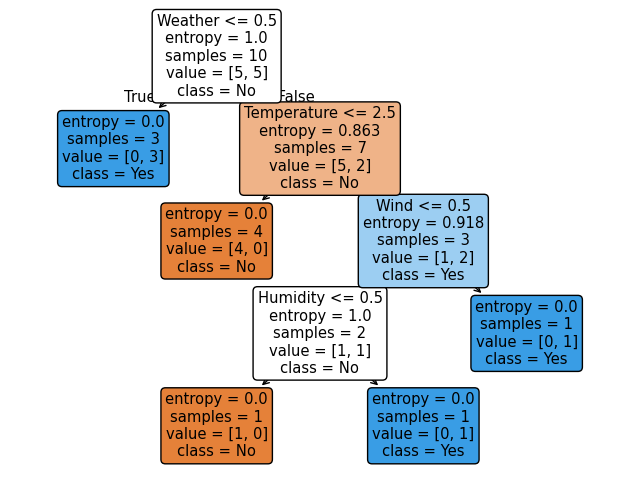

In [33]:
plt.figure(figsize=(8,6))

plot_tree(
    model,
    feature_names=x.columns,
    class_names=['No','Yes'],
    filled=True,
    rounded=True
)

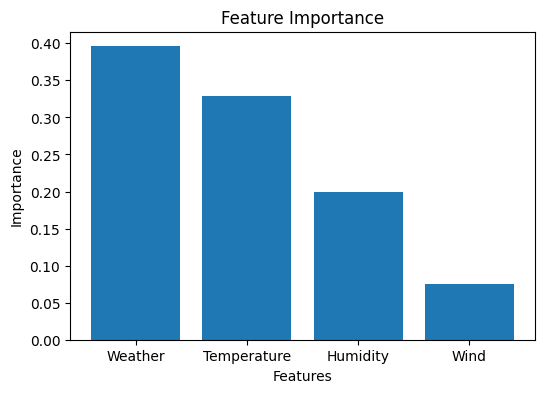

In [34]:
plt.figure(figsize=(6,4))

plt.bar(
  x.columns,
  model.feature_importances_
)

plt.title("Feature Importance")
plt.xlabel("Features")
plt.ylabel("Importance")
plt.show()

In [36]:
from sklearn.metrics import accuracy_score

y_pred = model.predict(x)
accuracy = accuracy_score(y,y_pred)

print("Accuracy",accuracy*100,"%")

Accuracy 100.0 %
